In [4]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt
import itertools
import csv

In [5]:
class BaseStation:
    def __init__(self, id, x, y, coverage_radius=65):
        """
        Αρχικοποιεί έναν σταθμό βάσης με μοναδικό ID, θέση, ακτίνα κάλυψης και αρχικό φορτίο.
        Args:
            id (int): Το ID του σταθμού βάσης.
            x (float): Η συντεταγμένη X του σταθμού βάσης.
            y (float): Η συντεταγμένη Y του σταθμού βάσης.
            coverage_radius (float): Η ακτίνα κάλυψης του σταθμού βάσης.
        """
        self.id = id  # Αποθήκευση του μοναδικού ID του σταθμού βάσης
        self.x = x  # Αποθήκευση της συντεταγμένης X του σταθμού βάσης
        self.y = y  # Αποθήκευση της συντεταγμένης Y του σταθμού βάσης
        self.coverage_radius = coverage_radius  # Ορισμός της ακτίνας κάλυψης του σταθμού βάσης
        self.load = random.uniform(0.1, 1.0)  # Τυχαία αρχικοποίηση του φορτίου του σταθμού βάσης
        self.connected_ues = 0  # Αριθμός συνδεδεμένων UEs (συσκευών χρηστών)

    def update_load(self):
        """
        Ενημερώνει το φορτίο του σταθμού βάσης με βάση τον αριθμό των συνδεδεμένων συσκευών UE.
        """
        self.load = self.connected_ues / 10 + random.uniform(0.5, 1.5)  # Υπολογισμός του νέου φορτίου με βάση τον αριθμό των συνδεδεμένων UEs και μια τυχαία διακύμανση
        self.load = max(0.1, min(1.0, self.load))  # Περιορισμός του φορτίου μεταξύ 0.1 και 1.0

    def get_signal_strength(self, ue):
        """
        Υπολογίζει την ισχύ σήματος (SNR) για μια συγκεκριμένη συσκευή UE.
        Args:
            ue (UE): Η συσκευή UE για την οποία υπολογίζεται η ισχύς του σήματος.
        Returns:
            float: Η τιμή της ισχύος του σήματος.
        """
        distance = math.sqrt((ue.x - self.x) ** 2 + (ue.y - self.y) ** 2)  # Υπολογισμός της απόστασης μεταξύ του σταθμού βάσης και του UE
        if distance == 0:
            return float('inf')  # Πολύ υψηλή ισχύς σήματος αν η UE είναι στην ακριβή θέση του σταθμού βάσης

        if distance > self.coverage_radius:
            return 0  # Μηδενικό σήμα αν το UE είναι εκτός της ακτίνας κάλυψης

        # Υπολογισμός SNR με προσθήκη διακύμανσης για προσομοίωση περιβαλλοντικού θορύβου
        fluctuation = np.random.normal(0, 0.002)
        snr = max(0, (1 / distance) + fluctuation)  # Υπολογισμός της ισχύος σήματος με διακύμανση
        return snr  # Επιστροφή της ισχύος σήματος


In [5]:
class BaseStation:
    def __init__(self, id, x, y, coverage_radius=65):
        """
        Αρχικοποιεί έναν σταθμό βάσης με μοναδικό ID, θέση, ακτίνα κάλυψης και αρχικό φορτίο.
        Args:
            id (int): Το ID του σταθμού βάσης.
            x (float): Η συντεταγμένη X του σταθμού βάσης.
            y (float): Η συντεταγμένη Y του σταθμού βάσης.
            coverage_radius (float): Η ακτίνα κάλυψης του σταθμού βάσης.
        """
        self.id = id  # Αποθήκευση του μοναδικού ID του σταθμού βάσης
        self.x = x  # Αποθήκευση της συντεταγμένης X του σταθμού βάσης
        self.y = y  # Αποθήκευση της συντεταγμένης Y του σταθμού βάσης
        self.coverage_radius = coverage_radius  # Ορισμός της ακτίνας κάλυψης του σταθμού βάσης
        self.load = random.uniform(0.1, 1.0)  # Τυχαία αρχικοποίηση του φορτίου του σταθμού βάσης
        self.connected_ues = 0  # Αριθμός συνδεδεμένων UEs (συσκευών χρηστών)

    def update_load(self):
        """
        Ενημερώνει το φορτίο του σταθμού βάσης με βάση τον αριθμό των συνδεδεμένων συσκευών UE.
        """
        self.load = self.connected_ues / 10 + random.uniform(0.5, 1.5)  # Υπολογισμός του νέου φορτίου με βάση τον αριθμό των συνδεδεμένων UEs και μια τυχαία διακύμανση
        self.load = max(0.1, min(1.0, self.load))  # Περιορισμός του φορτίου μεταξύ 0.1 και 1.0

    def get_signal_strength(self, ue):
        """
        Υπολογίζει την ισχύ σήματος (SNR) για μια συγκεκριμένη συσκευή UE.
        Args:
            ue (UE): Η συσκευή UE για την οποία υπολογίζεται η ισχύς του σήματος.
        Returns:
            float: Η τιμή της ισχύος του σήματος.
        """
        distance = math.sqrt((ue.x - self.x) ** 2 + (ue.y - self.y) ** 2)  # Υπολογισμός της απόστασης μεταξύ του σταθμού βάσης και του UE
        if distance == 0:
            return float('inf')  # Πολύ υψηλή ισχύς σήματος αν η UE είναι στην ακριβή θέση του σταθμού βάσης

        if distance > self.coverage_radius:
            return 0  # Μηδενικό σήμα αν το UE είναι εκτός της ακτίνας κάλυψης

        # Υπολογισμός SNR με προσθήκη διακύμανσης για προσομοίωση περιβαλλοντικού θορύβου
        fluctuation = np.random.normal(0, 0.002)
        snr = max(0, (1 / distance) + fluctuation)  # Υπολογισμός της ισχύος σήματος με διακύμανση
        return snr  # Επιστροφή της ισχύος σήματος


In [8]:
class UE:
    def __init__(self, id, x, y):
        """
        Αρχικοποιεί έναν Εξοπλισμό Χρήστη (UE) με ένα ID και θέση.
        Ορίσματα:
            id (int): Το ID του UE.
            x (float): Η συντεταγμένη X του UE.
            y (float): Η συντεταγμένη Y του UE.
        """
        self.id = id  # Αποθηκεύει το ID του UE
        self.x = x  # Αποθηκεύει τη συντεταγμένη X του UE
        self.y = y  # Αποθηκεύει τη συντεταγμένη Y του UE
        self.connected_station = None  # Ο σταθμός βάσης στον οποίο είναι συνδεδεμένη η συσκευή (αρχικά None).
        self.handover_delay = 0  # Συνολική καθυστέρηση εναλλαγής που έχει συσσωρευτεί
        self.handover_count = 0  # Αριθμός εναλλαγών που έχουν πραγματοποιηθεί
        self.history = [(x, y)]  # Παρακολούθηση ιστορικού κίνησης του UE
        self.communication_load = random.uniform(0.1, 1.0)  # Φορτίο επικοινωνίας για κάθε UE

    def move_randomly(self, step_size=1):
        """
        Μετακινεί το UE τυχαία μέσα σε ένα δεδομένο μέγεθος βήματος.
        Ορίσματα:
            step_size (float): Μέγιστη απόσταση για μετακίνηση προς οποιαδήποτε κατεύθυνση.
        """
        self.x += random.uniform(-step_size, step_size)  # Τυχαία μεταβολή στη συντεταγμένη X
        self.y += random.uniform(-step_size, step_size)  # Τυχαία μεταβολή στη συντεταγμένη Y
        self.history.append((self.x, self.y))  # Ενημέρωση ιστορικού κίνησης

    def move_linearly(self, x_speed, y_speed):
        """
        Μετακινεί το UE σε γραμμική κατεύθυνση.
        Ορίσματα:
            x_speed (float): Ταχύτητα στην κατεύθυνση x.
            y_speed (float): Ταχύτητα στην κατεύθυνση y.
        """
        self.x += x_speed  # Αύξηση της συντεταγμένης X με βάση την ταχύτητα
        self.y += y_speed  # Αύξηση της συντεταγμένης Y με βάση την ταχύτητα
        self.history.append((self.x, self.y))  # Ενημέρωση ιστορικού κίνησης

    def generate_custom_path(self, dataset, obstacle_probability=0.2, speed_limit=0.5):
        """
        Δημιουργεί μια προσαρμοσμένη διαδρομή χρησιμοποιώντας δεδομένα από ένα dataset,
        τροποποιώντας τη διαδρομή με βάση εμπόδια και όρια ταχύτητας.
        Args:
            dataset (list of tuples): Μια λίστα συντεταγμένων (πλάτος, μήκος) από το dataset.
            obstacle_probability (float): Πιθανότητα εμφάνισης εμποδίων.
            speed_limit (float): Όριο ταχύτητας για τη διαδρομή.
        Returns:
            list of tuples: Μια λίστα συντεταγμένων που αντιπροσωπεύουν την προσαρμοσμένη διαδρομή.
        """
        # Επιλέγουμε τυχαία τμήματα του dataset για ποικιλία
        path_length = random.randint(3, len(dataset))  # Τυχαίο μήκος διαδρομής
        start_index = random.randint(0, len(dataset) - path_length)  # Τυχαία αρχή
        path = dataset[start_index:start_index + path_length]  # Δημιουργία διαδρομής

        # Προσθήκη λογικής για εμπόδια
        modified_path = []
        for (lat, lon) in path:
            if random.random() < obstacle_probability:  # Έλεγχος αν υπάρχει εμπόδιο
                # Δημιουργία τυχαίας εναλλακτικής διαδρομής
                lat += random.uniform(-speed_limit, speed_limit)
                lon += random.uniform(-speed_limit, speed_limit)
            modified_path.append((lat, lon))

        return modified_path

    def move_custom(self, dataset):
        """Μετακινεί το UE κατά μήκος μιας προσαρμοσμένης διαδρομής που δημιουργείται από ένα dataset."""
        path = self.generate_custom_path(dataset)  # Δημιουργεί μια προσαρμοσμένη διαδρομή
        while path:  # Ελέγχει αν η διαδρομή δεν είναι κενή
            self.x, self.y = path.pop(0)  # Αναθέτει τις πρώτες συντεταγμένες της διαδρομής στις μεταβλητές x και y
            self.history.append((self.x, self.y))  # Προσθέτει τις τρέχουσες συντεταγμένες στο ιστορικό
            print(f"Moved to: ({self.x}, {self.y})")  # Εκτυπώνει την τρέχουσα θέση



In [4]:
class Network:
    def __init__(self, num_stations, num_ues, grid=False):
        """
        Initializes the network with base stations and UEs.
        Args:
            num_stations (int): Number of base stations.
            num_ues (int): Number of UEs.
            grid (bool): Whether to arrange base stations in a grid formation.
        """
        self.base_stations = self.create_base_stations(num_stations, grid)
        self.ues = self.create_ues(num_ues)

    def create_base_stations(self, num_stations, grid):
        if grid:
            # Create base stations in a grid pattern
            grid_size = int(math.sqrt(num_stations))
            spacing = 100 / (grid_size - 1) if grid_size > 1 else 100
            return [
                BaseStation(
                    i, (i % grid_size) * spacing, (i // grid_size) * spacing, coverage_radius=70
                )
                for i in range(num_stations)
            ]
        else:
            # Create base stations with random positions
            return [
                BaseStation(i, random.uniform(0, 100), random.uniform(0, 100), random.uniform(60, 70))
                for i in range(num_stations)
            ]

    def create_ues(self, num_ues):
        return [UE(i, random.uniform(0, 100), random.uniform(0, 100)) for i in range(num_ues)]

    def rssi_based_handover(self, ue, hysteresis_margin=0.05):
        """
        Perform a handover for the UE based on the strongest signal strength with hysteresis.
        Args:
            ue (UE): The UE object that may need a handover.
            hysteresis_margin (float): The margin by which the new signal must exceed the current signal to trigger a handover.
        """
        current_signal = ue.connected_station.get_signal_strength(ue) if ue.connected_station else 0
        best_station = ue.connected_station

        for station in self.base_stations:
            signal_strength = station.get_signal_strength(ue)
            if signal_strength > current_signal * (1 + hysteresis_margin):  # Hysteresis margin to reduce frequent switching
                best_station = station

        if best_station != ue.connected_station:
            self.execute_handover(ue, best_station)

    def threshold_based_handover(self, ue, threshold=0.3):
        """
        Perform a handover if the current signal strength drops below a certain threshold.
        Args:
            ue (UE): The UE object that may need a handover.
            threshold (float): Signal strength threshold below which a handover is triggered.
        """
        current_signal = ue.connected_station.get_signal_strength(ue) if ue.connected_station else 0
        best_station = ue.connected_station

        for station in self.base_stations:
            signal_strength = station.get_signal_strength(ue)
            if signal_strength > current_signal:
                best_station = station

        if current_signal < threshold and best_station != ue.connected_station:
            self.execute_handover(ue, best_station)

    def cost_based_handover(self, ue):
        """
        Perform a handover for the UE based on a cost function that considers load, signal strength, and distance.
        Args:
            ue (UE): The UE object that may need a handover.
        """
        best_station = min(self.base_stations, key=lambda s: self.calculate_cost(s, ue))
        if ue.connected_station != best_station:
            self.execute_handover(ue, best_station)

    def execute_handover(self, ue, new_station):
        """
        Execute the handover for the UE to a new base station.
        Args:
            ue (UE): The UE object that is executing the handover.
            new_station (BaseStation): The new base station to connect to.
        """
        ue.handover_count += 1
        if ue.connected_station:
            ue.connected_station.connected_ues -= 1
        new_station.connected_ues += 1
        fixed_delay = 0.2
        variable_delay = (self.calculate_cost(new_station, ue) / 100)
        ue.handover_delay += fixed_delay + min(variable_delay, 1)
        ue.connected_station = new_station

    def calculate_cost(self, station, ue):
        """
        Calculate the cost of connecting to a given base station, considering signal strength, load, and distance.
        Args:
            station (BaseStation): The base station being evaluated.
            ue (UE): The UE for which the cost is calculated.
        Returns:
            float: The cost value for the connection.
        """
        distance = math.sqrt((ue.x - station.x) ** 2 + (ue.y - station.y) ** 2)
        signal_strength = station.get_signal_strength(ue)

        if signal_strength == 0:
            return float('inf')  # Infinite cost if there is no signal

        # More aggressive weighting of load and distance, and introducing a handover penalty
        cost = (distance * station.load * 10) / (signal_strength + 1)

        # Introduce a handover penalty to discourage frequent handovers
        handover_penalty = 50
        if ue.connected_station != station:
            cost += handover_penalty

        return cost

    def run_simulation(self, steps=100, handover_algorithm='rssi', mobility_pattern='random', custom_path=None):
        """
        Run the simulation for a set number of steps.
        Args:
            steps (int): Number of steps in the simulation.
            handover_algorithm (str): The handover algorithm to use ('rssi', 'threshold', 'cost').
            mobility_pattern (str): The mobility pattern for the UEs ('random', 'linear', 'custom').
            custom_path (list): A custom path for UEs, if applicable.
        """
        for _ in range(steps):
            for ue in self.ues:
                if mobility_pattern == 'random':
                    ue.move_randomly()
                elif mobility_pattern == 'linear':
                    ue.move_linearly(x_speed=1, y_speed=0.5)
                elif mobility_pattern == 'custom' and custom_path:
                    ue.move_custom(custom_path)

                # Handover algorithm selection
                if handover_algorithm == 'rssi':
                    self.rssi_based_handover(ue)
                elif handover_algorithm == 'threshold':
                    self.threshold_based_handover(ue)
                elif handover_algorithm == 'cost':
                    self.cost_based_handover(ue)

            for station in self.base_stations:
                station.update_load()

    def analyze_performance(self):
        """
        Analyze the performance of the network in terms of handovers and delays.
        Returns:
            tuple: Total handovers and average delay.
        """
        total_handovers = sum(ue.handover_count for ue in self.ues)
        avg_delay = sum(ue.handover_delay for ue in self.ues) / len(self.ues)
        print(f"Total Handovers: {total_handovers}, Avg Delay: {avg_delay}")
        return total_handovers, avg_delay

    def plot_handover_distribution(self):
        """
        Plot the distribution of handovers across UEs.
        """
        handover_counts = [ue.handover_count for ue in self.ues]
        plt.hist(handover_counts, bins=range(0, max(handover_counts) + 1), edgecolor='black')
        plt.title('Handover Count Distribution')
        plt.xlabel('Number of Handovers')
        plt.ylabel('Number of UEs')
        plt.show()

    def plot_handover_delay_distribution(self):
        """
        Plot the distribution of handover delays across UEs.
        """
        handover_delays = [ue.handover_delay for ue in self.ues if ue.handover_delay != float('inf')]
        if handover_delays:
            plt.hist(handover_delays, bins=10, edgecolor='black')
            plt.title('Handover Delay Distribution')
            plt.xlabel('Handover Delay (s)')
            plt.ylabel('Number of UEs')
            plt.show()
        else:
            print("No valid handover delays to plot.")

    def plot_ue_movements(self, title):
        """
        Plot the movement paths of all UEs.
        Args:
            title (str): Title of the plot.
        """
        plt.figure()
        for ue in self.ues:
            x_coords, y_coords = zip(*ue.history)
            plt.plot(x_coords, y_coords, label=f'UE {ue.id}')

        base_station_positions = [(station.x, station.y) for station in self.base_stations]
        bs_x, bs_y = zip(*base_station_positions)
        plt.scatter(bs_x, bs_y, color='red', marker='x', label='Base Stations')

        plt.title(title)
        plt.xlabel('X Coordinate')
        plt.ylabel('Y Coordinate')
        plt.legend()
        plt.show()

    def plot_network_topology(self, mobility_pattern='random', custom_path=None):
        """
        Plot the network topology, including base stations and UE movements.
        Args:
            mobility_pattern (str): The mobility pattern for UEs.
            custom_path (list): Custom path for UEs if applicable.
        """
        plt.figure(figsize=(10, 10))

        # Plot the base stations
        for station in self.base_stations:
            station_circle = plt.Circle((station.x, station.y), station.coverage_radius, color='blue', fill=False)
            plt.gca().add_patch(station_circle)
            plt.plot(station.x, station.y, 'bx', label=f'Base Station {station.id}')

        # Plot UE positions and movement
        for ue in self.ues:
            x_coords, y_coords = zip(*ue.history)
            plt.plot(x_coords, y_coords, label=f'UE {ue.id}')
            plt.plot(x_coords[0], y_coords[0], 'go')  # Mark starting point with a green circle
            plt.plot(x_coords[-1], y_coords[-1], 'ro')  # Mark ending point with a red circle

        plt.title(f'Network Topology with {mobility_pattern.capitalize()} Movements')
        plt.xlabel('X Coordinate')
        plt.ylabel('Y Coordinate')
        plt.grid(True)
        plt.legend()
        plt.show()

Total Handovers: 105, Avg Delay: 12.549071775033621


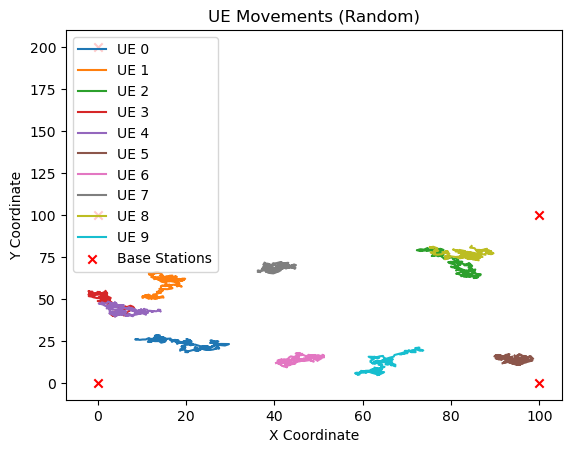

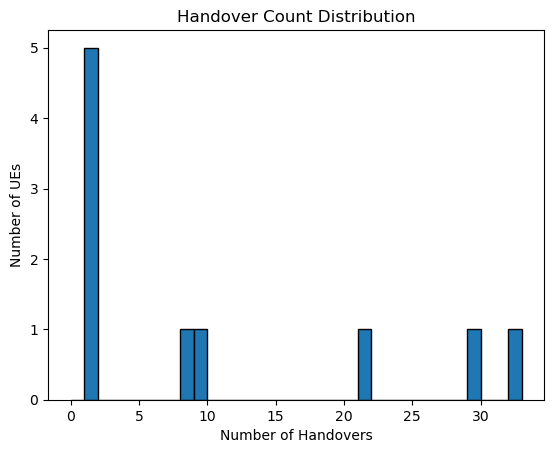

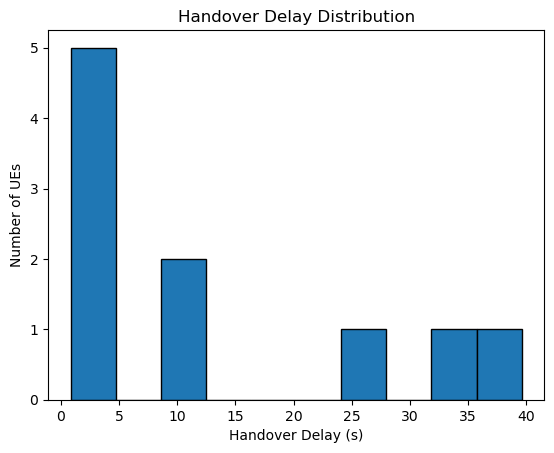

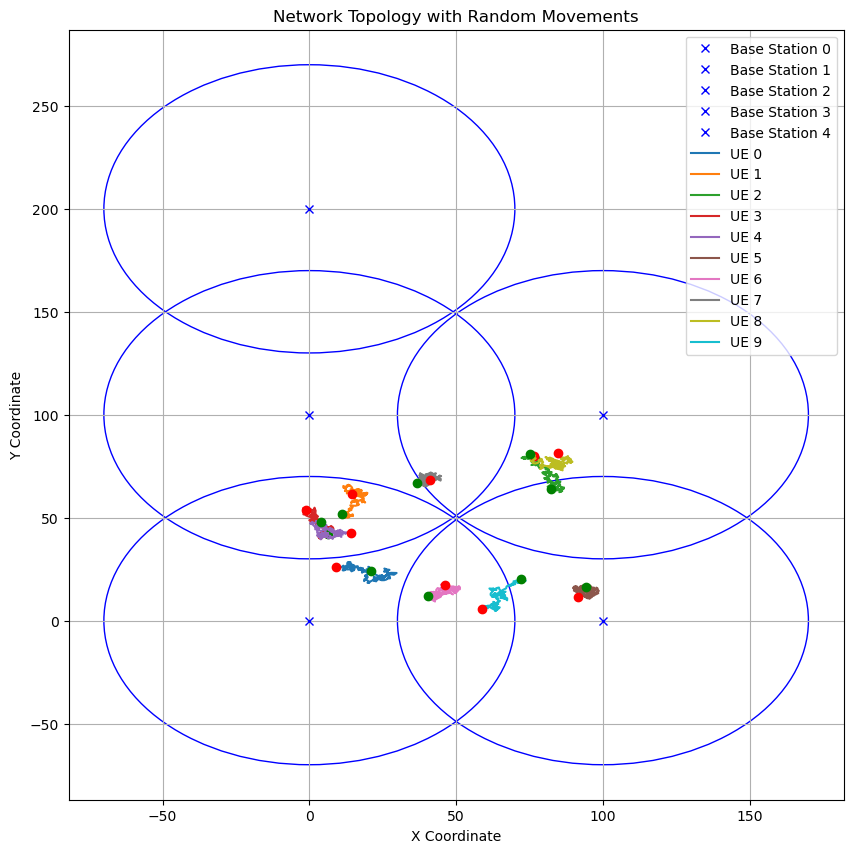

In [5]:
# Example usage for each movement pattern:

# Network with random movement using RSSI-based handover
network_random = Network(num_stations=5, num_ues=10, grid=True)
network_random.run_simulation(steps=200, handover_algorithm='rssi', mobility_pattern='random')
network_random.analyze_performance()
network_random.plot_ue_movements('UE Movements (Random)')
network_random.plot_handover_distribution()
network_random.plot_handover_delay_distribution()
network_random.plot_network_topology(mobility_pattern='random')

Total Handovers: 43, Avg Delay: 5.16


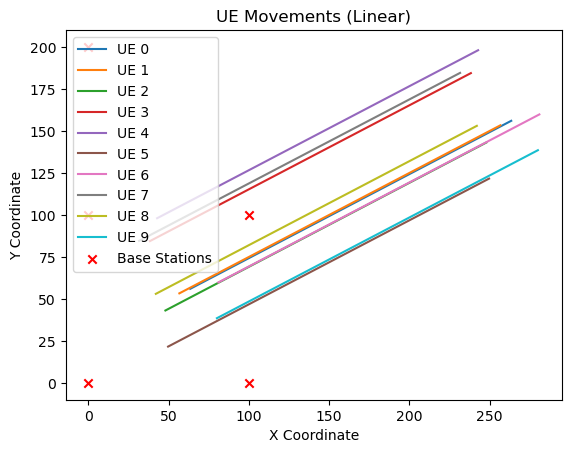

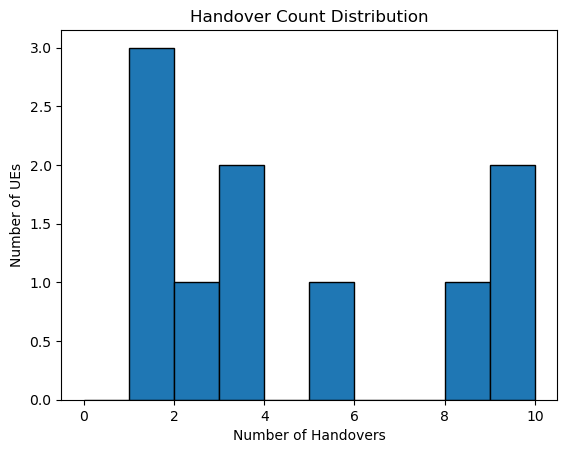

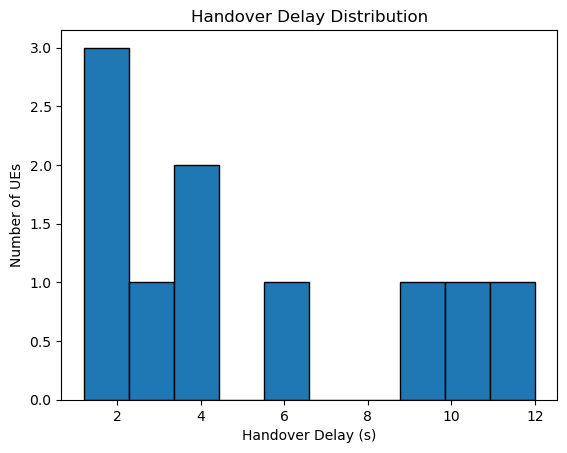

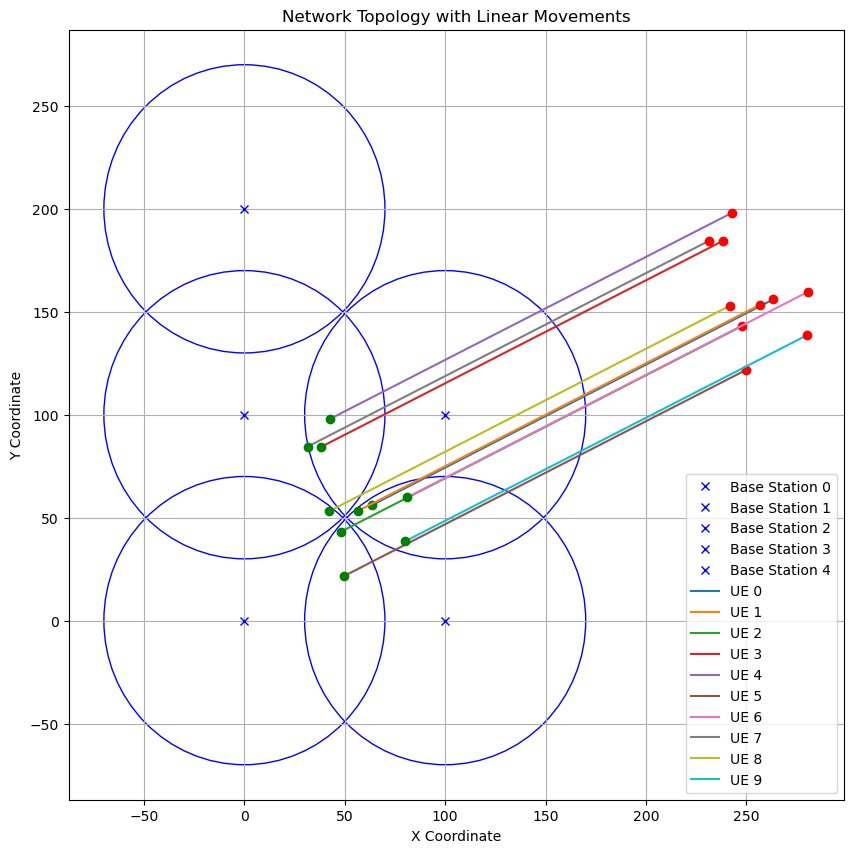

In [6]:
# Network with linear movement using threshold-based handover
network_linear = Network(num_stations=5, num_ues=10, grid=True)
network_linear.run_simulation(steps=200, handover_algorithm='threshold', mobility_pattern='linear')
network_linear.analyze_performance()
network_linear.plot_ue_movements('UE Movements (Linear)')
network_linear.plot_handover_distribution()
network_linear.plot_handover_delay_distribution()
network_linear.plot_network_topology(mobility_pattern='linear')

Total Handovers: 44, Avg Delay: 4.958679140165684


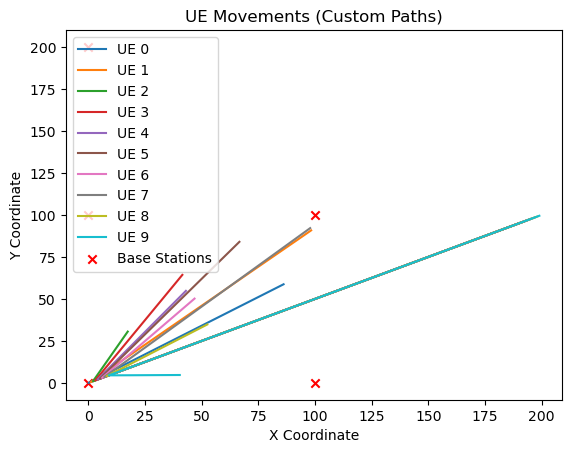

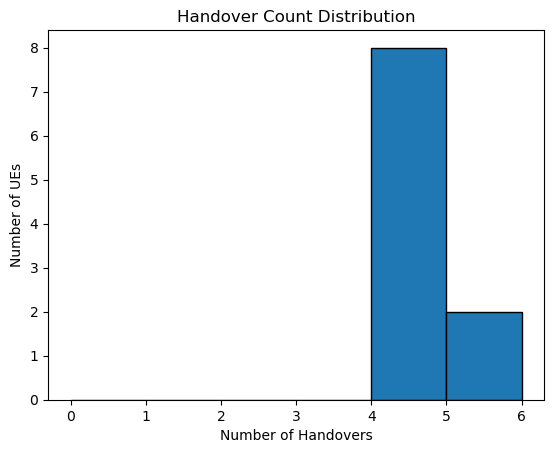

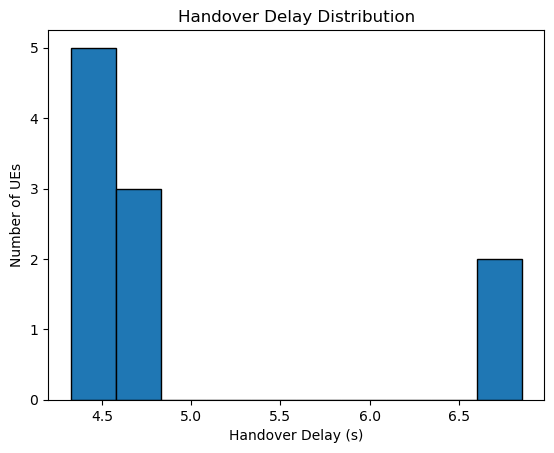

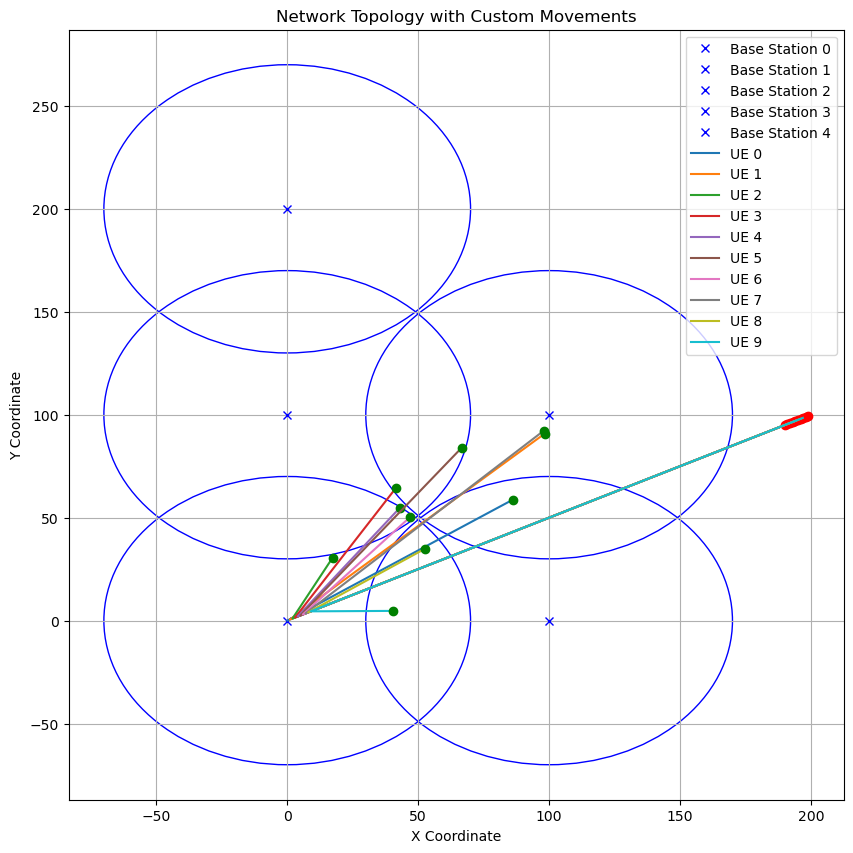

In [7]:
# Network with custom paths using cost-based handover
network_custom = Network(num_stations=5, num_ues=10, grid=True)
custom_path = [(i, i * 0.5) for i in range(200)]  # Example custom path
network_custom.run_simulation(steps=200, handover_algorithm='cost', mobility_pattern='custom', custom_path=custom_path)
network_custom.analyze_performance()
network_custom.plot_ue_movements('UE Movements (Custom Paths)')
network_custom.plot_handover_distribution()
network_custom.plot_handover_delay_distribution()
network_custom.plot_network_topology(mobility_pattern='custom')


In [12]:
# Παράδειγμα χρήσης
dataset = [
    (-10.9393413858164, -37.0627421097422),
    (-10.939341385769, -37.0627421097809),
    (-10.9393239478718, -37.0627645137212),
    (-10.9392105616561, -37.0628430455445),
    (-10.9389389789911, -37.0628785984113),
    (-10.9385435911514, -37.0628386631358),
    (-10.9383460576505, -37.0625875627021),
    (-10.9384484455051, -37.0619998251528),
    (-10.9386660746204, -37.0614989339645),
    (-10.9389862284613, -37.0608192197261),
    (-10.9393429131892, -37.0600866959415)
]

# Δημιουργία ενός UE και κίνηση κατά μήκος της προσαρμοσμένης διαδρομής
ue = UE(id=1, x=-10.9393413858164, y=-37.0627421097422)
ue.move_custom(dataset)

Moved to: (-10.9393413858164, -37.0627421097422)
Moved to: (-10.939341385769, -37.0627421097809)
Moved to: (-10.9393239478718, -37.0627645137212)
Moved to: (-10.9392105616561, -37.0628430455445)
Moved to: (-10.9389389789911, -37.0628785984113)
Moved to: (-10.9385435911514, -37.0628386631358)
Moved to: (-10.9383460576505, -37.0625875627021)
Moved to: (-10.9384484455051, -37.0619998251528)
Moved to: (-10.9386660746204, -37.0614989339645)
Moved to: (-10.9389862284613, -37.0608192197261)
